# Disaster Recovery Cost Prediction and Resilience Optimization
## Week 2 Day 4 — Model Evaluation and Explainability

## Goal of this notebook

The purpose of this notebook is to evaluate the best-performing disaster recovery cost model on a holdout test set and explain how the model makes predictions.

This notebook includes:
- loading the saved best model pipeline
- creating a proper train/test split for honest evaluation
- generating prediction diagnostics
- evaluating performance across key groups
- extracting feature importance
- computing SHAP values
- saving a SHAP summary plot for reporting

In [1]:
import json
import pickle
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import shap

from sklearn.base import clone
from sklearn.metrics import (
    r2_score,
    mean_squared_error,
    mean_absolute_error
)
from sklearn.model_selection import train_test_split

pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)
sns.set_theme(style="whitegrid")

PROJECT_ROOT = Path.cwd().parent
DATA_PATH = PROJECT_ROOT / "data" / "processed" / "processed_disasters.csv"
MODEL_PATH = PROJECT_ROOT / "models" / "best_model.pkl"
METADATA_PATH = PROJECT_ROOT / "models" / "best_model_metadata.json"
SHAP_OUTPUT_PATH = PROJECT_ROOT / "models" / "shap_summary.png"

## Section B — Load the Processed Dataset and Saved Model

The saved model pipeline from Day 3 contains the preprocessing and estimator steps. The processed dataset contains the disaster-level features and target.

In [2]:
df = pd.read_csv(DATA_PATH)

with open(MODEL_PATH, "rb") as f:
    saved_pipeline = pickle.load(f)

with open(METADATA_PATH, "r", encoding="utf-8") as f:
    metadata = json.load(f)

print("Dataset shape:", df.shape)
print("Saved best model:", metadata["best_model_name"])
print("Numeric features:", metadata["numeric_features"])
print("Categorical features:", metadata["categorical_features"])

Dataset shape: (5163, 43)
Saved best model: random_forest
Numeric features: ['declaration_year', 'declaration_month', 'incident_duration_days', 'state_5yr_disaster_count', 'high_cost_incident', 'fyDeclared', 'tribalRequest', 'fipsStateCode', 'fipsCountyCode', 'placeCode', 'region']
Categorical features: ['state', 'incidentType', 'declarationType', 'season', 'census_region']


## Section C — Prepare Features and Target

To avoid optimistic evaluation, the saved fitted pipeline will be cloned and re-fitted on a train split before generating test predictions.

In [3]:
target_col = metadata["target_column"]
numeric_features = metadata["numeric_features"]
categorical_features = metadata["categorical_features"]

feature_cols = numeric_features + categorical_features

X = df[feature_cols].copy()
y = df[target_col].copy()

# Keep some reference columns for grouped evaluation
reference_cols = ["incidentType", "census_region", "state", "season"]
reference_cols = [col for col in reference_cols if col in df.columns]

X_ref = df[reference_cols].copy()

## Section D — Create Holdout Test Set and Refit Best Pipeline

Although a fitted best model already exists, it was trained on the full dataset. For honest evaluation, we clone that pipeline structure and fit it only on the training split.

In [4]:
X_train, X_test, y_train, y_test, ref_train, ref_test = train_test_split(
    X,
    y,
    X_ref,
    test_size=0.2,
    random_state=42
)

evaluation_pipeline = clone(saved_pipeline)
evaluation_pipeline.fit(X_train, y_train)

y_pred = evaluation_pipeline.predict(X_test)

print("Train shape:", X_train.shape)
print("Test shape:", X_test.shape)

Train shape: (4130, 16)
Test shape: (1033, 16)


## Section E — Overall Test Performance

This section reports the model’s predictive performance on the unseen test set.

In [5]:
test_r2 = r2_score(y_test, y_pred)
test_rmse = np.sqrt(mean_squared_error(y_test, y_pred))
test_mae = mean_absolute_error(y_test, y_pred)

metrics_df = pd.DataFrame({
    "metric": ["R2", "RMSE", "MAE"],
    "value": [test_r2, test_rmse, test_mae]
})

display(metrics_df)

,metric,value
0,R2,0.893947
1,RMSE,2.919370
2,MAE,1.199830


## Section F — Predicted vs Actual

A well-performing model should produce predictions that lie close to the 45-degree line.

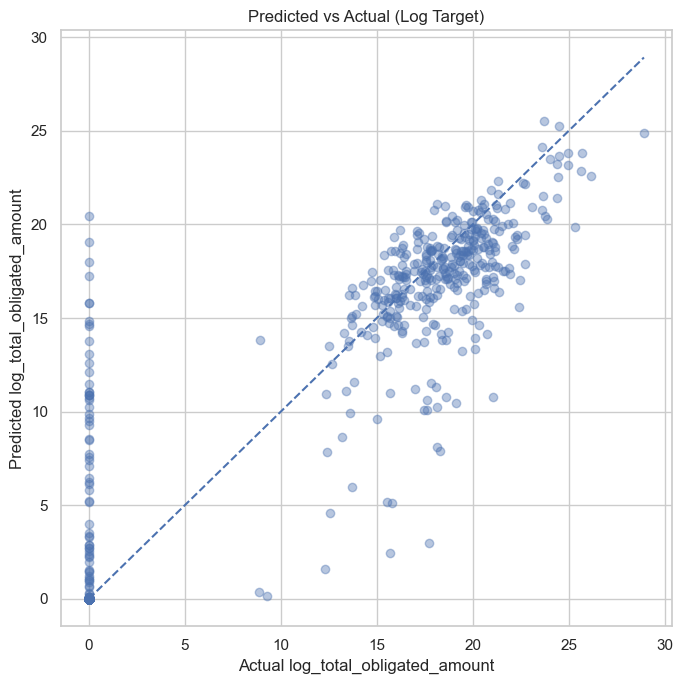

In [7]:
plt.figure(figsize=(7, 7))
plt.scatter(y_test, y_pred, alpha=0.4)
min_val = min(y_test.min(), y_pred.min())
max_val = max(y_test.max(), y_pred.max())
plt.plot([min_val, max_val], [min_val, max_val], linestyle="--")
plt.title("Predicted vs Actual (Log Target)")
plt.xlabel("Actual log_total_obligated_amount")
plt.ylabel("Predicted log_total_obligated_amount")
plt.tight_layout()
plt.show()

### 🔍 Section F — Predicted vs Actual Findings

The predicted vs actual scatter plot shows a strong linear relationship between predicted and actual values, indicating that the model captures the overall trend in disaster recovery costs effectively.

Most observations cluster tightly around the 45-degree reference line, demonstrating good predictive accuracy for the majority of cases. However, there is a clear vertical concentration of points at **actual ≈ 0**, where predictions vary widely. This suggests that the model struggles with zero or near-zero cost disasters, likely due to the log transformation and imbalance in low-cost observations.

At higher cost levels, predictions remain relatively accurate but show slight dispersion, indicating some variability in predicting extreme events.

**Key insights:**
- Strong overall predictive alignment  
- Good performance on medium–high cost disasters  
- Weak performance on zero/near-zero cost cases  
- Slight under/over-dispersion at extreme values  


## Section G — Residual Distribution

Residuals are calculated as actual minus predicted values. A good model should produce residuals that are centered around zero.

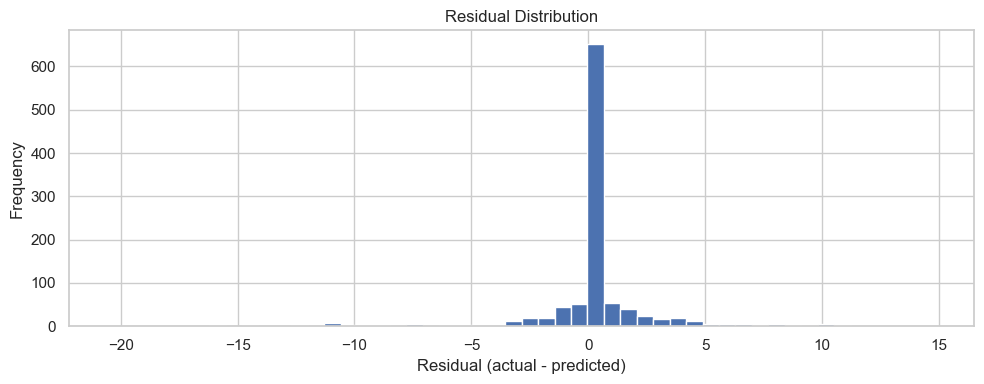

In [8]:
residuals = y_test - y_pred

plt.figure(figsize=(10, 4))
plt.hist(residuals, bins=50)
plt.title("Residual Distribution")
plt.xlabel("Residual (actual - predicted)")
plt.ylabel("Frequency")
plt.tight_layout()
plt.show()

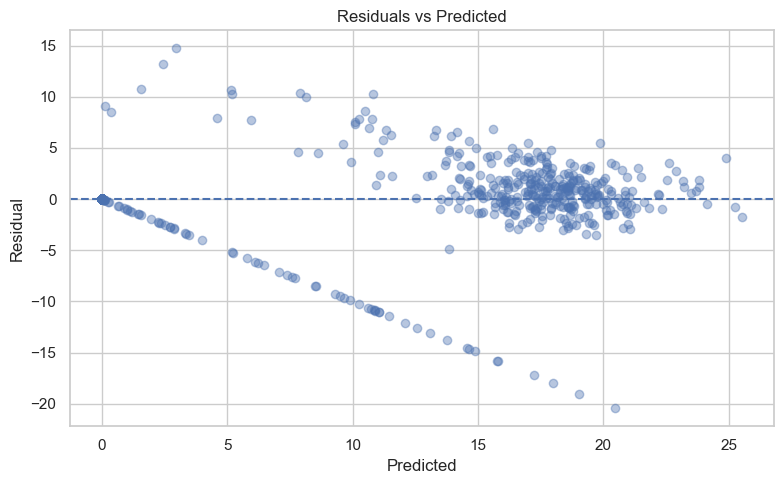

In [9]:
plt.figure(figsize=(8, 5))
plt.scatter(y_pred, residuals, alpha=0.4)
plt.axhline(0, linestyle="--")
plt.title("Residuals vs Predicted")
plt.xlabel("Predicted")
plt.ylabel("Residual")
plt.tight_layout()
plt.show()

### 📉 Section G — Residual Analysis Findings

The residual distribution is centered around zero, which confirms that the model is not systematically biased toward overprediction or underprediction.

However, the distribution is slightly skewed and exhibits long tails, particularly on the negative side, indicating occasional large prediction errors.

The residuals vs predicted plot reveals a **clear diagonal pattern**, especially for low predicted values. This indicates that:
- The model struggles with very low-cost disasters  
- Errors increase in magnitude for certain ranges  
- There may still be structure in the errors (not purely random)  

**Key insights:**
- Residuals are generally centered → good model calibration  
- Presence of heteroscedasticity (error spread varies with prediction level)  
- Model performs less reliably on low-cost disasters  
- Some systematic structure remains → room for improvement  


## Section H — Performance by Incident Type

This section checks whether the model performs equally well across different disaster categories.

In [10]:
eval_df = ref_test.copy()
eval_df["actual"] = y_test.values
eval_df["predicted"] = y_pred
eval_df["abs_error"] = np.abs(eval_df["actual"] - eval_df["predicted"])
eval_df["squared_error"] = (eval_df["actual"] - eval_df["predicted"]) ** 2

incident_perf = (
    eval_df.groupby("incidentType")
    .agg(
        count=("actual", "size"),
        mae=("abs_error", "mean"),
        rmse=("squared_error", lambda x: np.sqrt(np.mean(x))),
    )
    .reset_index()
    .sort_values("count", ascending=False)
)

display(incident_perf.head(10))

,incidentType,count,mae,rmse
4,Fire,331,0.217742,1.282330
13,Severe Storm,245,2.166270,3.894555
6,Flood,184,0.629732,1.949489
9,Hurricane,97,2.647261,4.302411
14,Snowstorm,40,0.700904,1.136726
16,Tornado,34,0.945651,3.414882
0,Biological,33,3.144551,4.584407
18,Typhoon,13,0.722515,1.485892
12,Severe Ice Storm,12,1.748490,2.428976
2,Drought,10,0.039240,0.097984


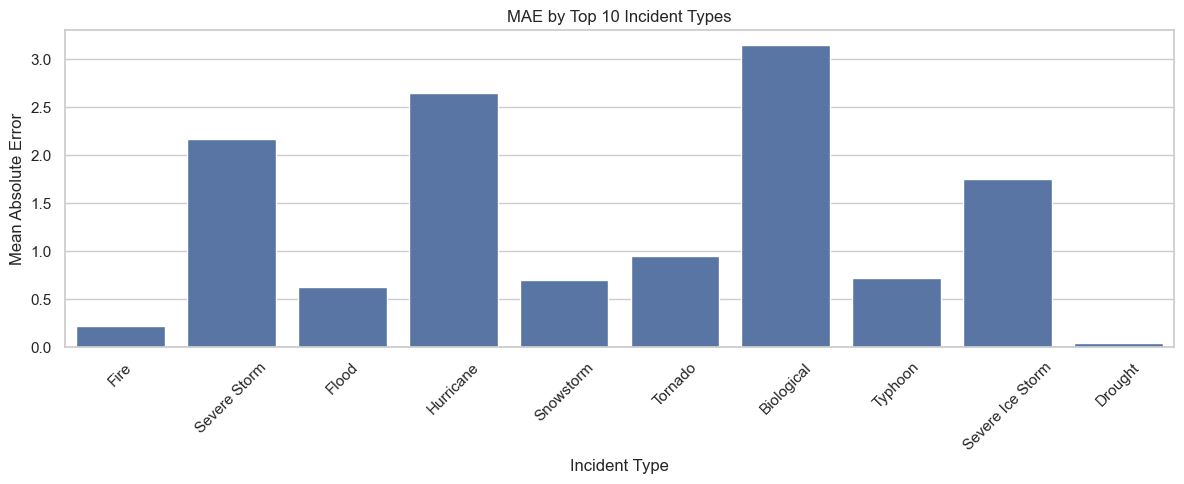

In [11]:
top_incidents = incident_perf.head(10)["incidentType"]

plot_df = incident_perf[incident_perf["incidentType"].isin(top_incidents)]

plt.figure(figsize=(12, 5))
sns.barplot(data=plot_df, x="incidentType", y="mae")
plt.title("MAE by Top 10 Incident Types")
plt.xlabel("Incident Type")
plt.ylabel("Mean Absolute Error")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

### 🌪️ Section H — Performance by Incident Type Findings

Model performance varies significantly across different disaster types.

High-frequency disaster types such as **Fire, Flood, and Snowstorm** show relatively low error rates, indicating that the model learns well from abundant data.

In contrast, disaster types like:
- **Hurricane**
- **Severe Storm**
- **Biological events**

show substantially higher MAE and RMSE values. These events tend to be:
- more complex  
- higher impact  
- more variable in cost  

Rare disaster types (e.g., Drought, Typhoon) show low error, but this is likely due to **small sample sizes rather than true model performance**.

**Key insights:**
- Model performs best on frequent, consistent disaster types  
- High-impact disasters are harder to predict accurately  
- Data imbalance affects performance across categories  
- Rare classes give unreliable performance signals  

## Section I — Performance by Census Region

This section checks whether model performance differs by region.

In [12]:
region_perf = (
    eval_df.groupby("census_region")
    .agg(
        count=("actual", "size"),
        mae=("abs_error", "mean"),
        rmse=("squared_error", lambda x: np.sqrt(np.mean(x))),
    )
    .reset_index()
    .sort_values("count", ascending=False)
)

display(region_perf)

,census_region,count,mae,rmse
2,South,373,1.489160,3.538488
5,West,327,0.563845,1.906971
0,Midwest,184,1.355202,2.866377
1,Northeast,117,1.921856,3.414929
3,Territory,26,0.958018,1.618630
4,Unknown,6,0.077926,0.190878


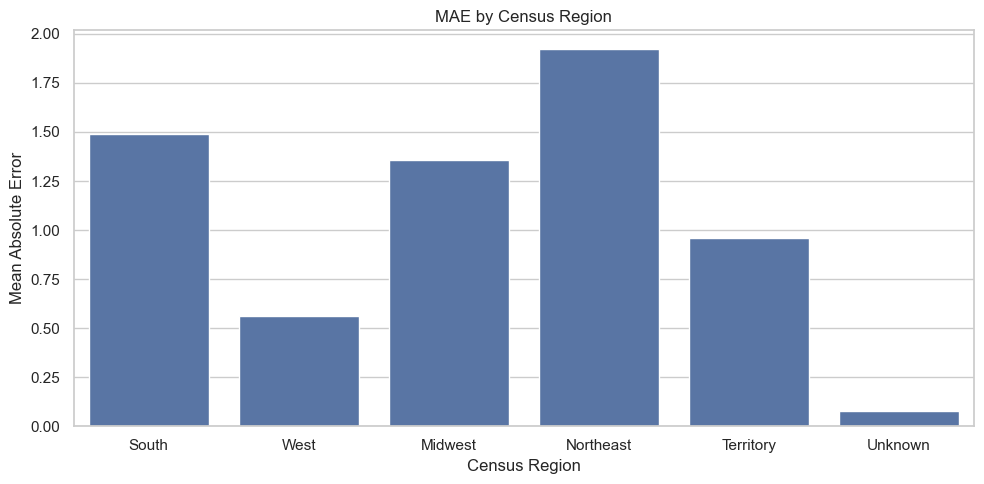

In [13]:
plt.figure(figsize=(10, 5))
sns.barplot(data=region_perf, x="census_region", y="mae")
plt.title("MAE by Census Region")
plt.xlabel("Census Region")
plt.ylabel("Mean Absolute Error")
plt.tight_layout()
plt.show()

### 🌍 Section I — Performance by Census Region Findings

The model shows variation in performance across geographic regions.

- **West region** has the lowest error → most stable predictions  
- **South and Midwest** show moderate error levels  
- **Northeast** exhibits the highest error → likely due to:
  - higher variability in disaster types  
  - fewer consistent patterns  

Regions with very low sample sizes (e.g., "Unknown") show artificially low error and should not be overinterpreted.

**Key insights:**
- Geographic variation affects prediction quality  
- Model performs best in regions with consistent patterns  
- Regions with diverse disasters are harder to model  
- Sample size strongly influences error reliability  

## Section J — Feature Importance

For tree-based models such as Random Forest or XGBoost, impurity-based feature importance provides a simple first view of which variables drive predictions most strongly.

In [14]:
fitted_preprocessor = evaluation_pipeline.named_steps["preprocessor"]
fitted_model = evaluation_pipeline.named_steps["model"]

feature_names = fitted_preprocessor.get_feature_names_out()

if hasattr(fitted_model, "feature_importances_"):
    importance_values = fitted_model.feature_importances_
elif hasattr(fitted_model, "coef_"):
    importance_values = np.abs(fitted_model.coef_)
else:
    raise ValueError("Model does not support simple feature importance extraction.")

feature_importance_df = pd.DataFrame({
    "feature": feature_names,
    "importance": importance_values
}).sort_values("importance", ascending=False)

display(feature_importance_df.head(20))

,feature,importance
0,num__declaration_year,0.435085
99,cat__declarationType_FM,0.194550
97,cat__declarationType_DR,0.100663
98,cat__declarationType_EM,0.074700
5,num__fyDeclared,0.040243
2,num__incident_duration_days,0.024273
3,num__state_5yr_disaster_count,0.022043
9,num__placeCode,0.010709
1,num__declaration_month,0.008786
7,num__fipsStateCode,0.008048


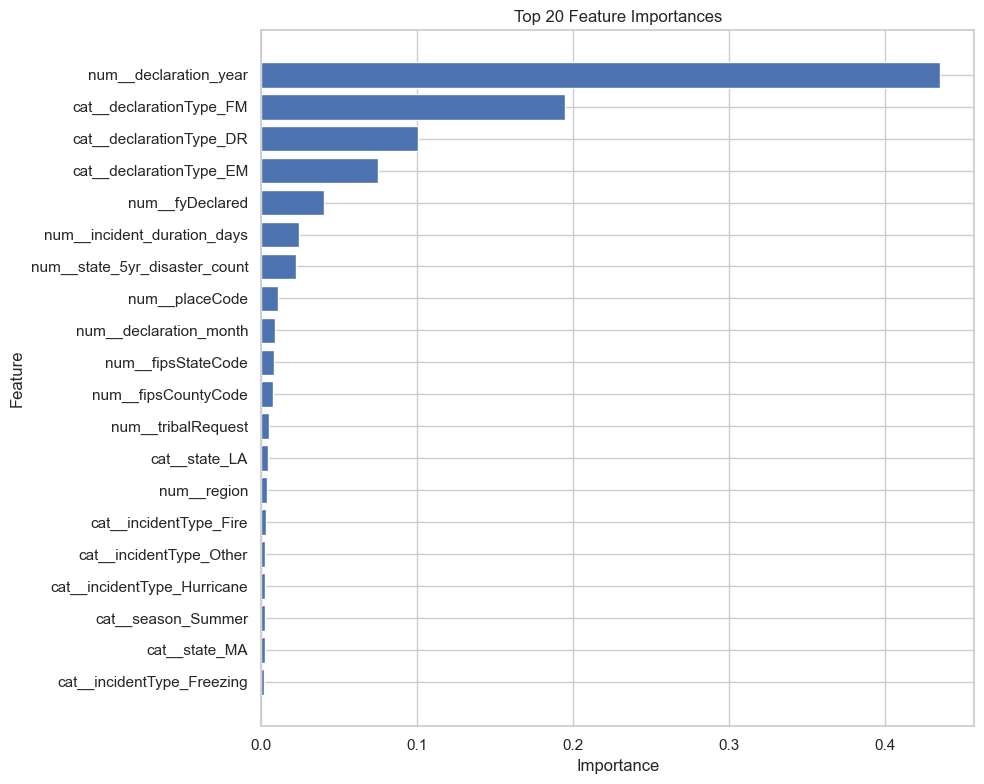

In [15]:
top_n = 20
plot_importance = feature_importance_df.head(top_n).sort_values("importance", ascending=True)
plt.figure(figsize=(10, 8))
plt.barh(plot_importance["feature"], plot_importance["importance"])
plt.title(f"Top {top_n} Feature Importances")
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()

### 📊 Section J — Feature Importance Findings

Feature importance analysis shows that the model is heavily driven by temporal and declaration-related variables.

The most important features include:
- **declaration_year (dominant driver)**  
- **declarationType (FM, DR, EM)**  
- **fyDeclared**  
- **incident_duration_days**  
- **state_5yr_disaster_count**  

This indicates that:
- Time and policy context strongly influence disaster cost  
- Government declaration types are key cost drivers  
- Historical disaster frequency contributes meaningfully  

Geographic and categorical features (state, incident type) have relatively lower importance individually but collectively contribute through encoding.

**Key insights:**
- Temporal features dominate predictions  
- Policy-related variables are highly influential  
- Historical frequency adds predictive value  
- Model relies less on raw incident type than expected  


## Section K — SHAP Analysis

SHAP values provide local and global explainability by showing how individual features push predictions up or down.

In [16]:
# Sample the test set for SHAP to keep runtime reasonable
shap_sample_size = min(500, len(X_test))
X_test_sample = X_test.sample(shap_sample_size, random_state=42)

X_test_transformed = fitted_preprocessor.transform(X_test_sample)

if hasattr(X_test_transformed, "toarray"):
    X_test_transformed = X_test_transformed.toarray()

In [17]:
# Tree-based SHAP
if hasattr(fitted_model, "feature_importances_"):
    explainer = shap.TreeExplainer(fitted_model)
    shap_values = explainer.shap_values(X_test_transformed)
else:
    raise ValueError("Current notebook SHAP setup is designed for tree-based models.")

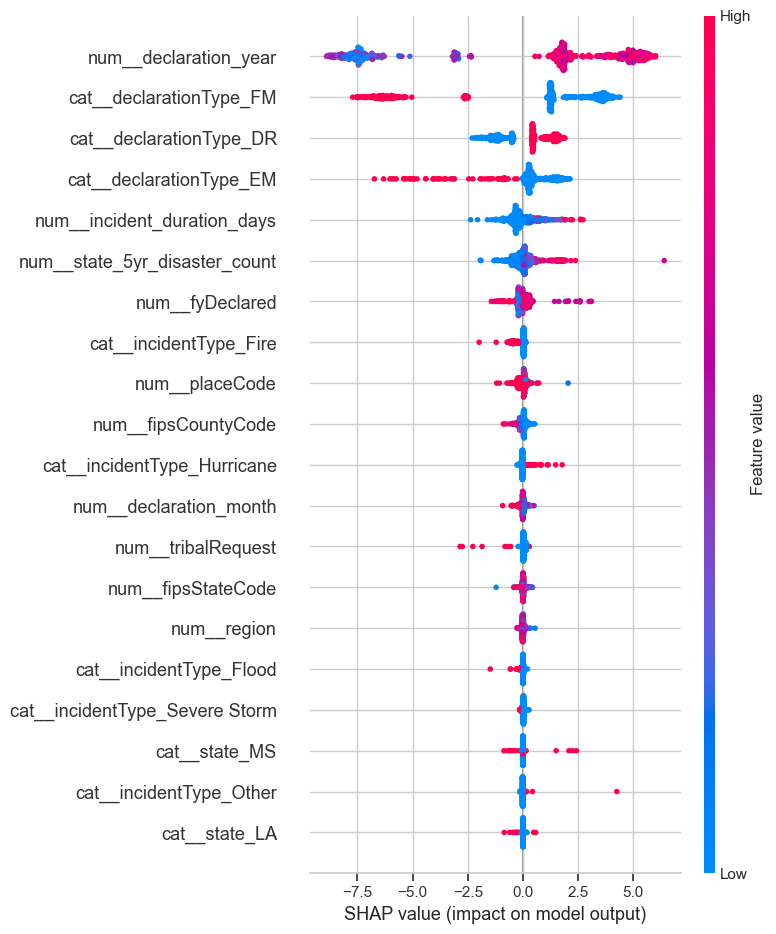

Saved SHAP summary plot to: C:\Users\caspe\OneDrive\Documents\disaster-recovery-cost-prediction\models\shap_summary.png


In [18]:
plt.figure()
shap.summary_plot(
    shap_values,
    X_test_transformed,
    feature_names=feature_names,
    show=False
)
plt.tight_layout()
plt.savefig(SHAP_OUTPUT_PATH, dpi=300, bbox_inches="tight")
plt.show()

print("Saved SHAP summary plot to:", SHAP_OUTPUT_PATH)

### 🧠 Section K — SHAP Analysis Findings

The SHAP summary plot provides a deeper and more reliable interpretation of feature impact.

It confirms that:
- **declaration_year is the strongest global driver**
  - Higher values → higher predicted costs  
- **declarationType features (FM, DR, EM)** strongly influence predictions  
- **incident_duration_days** increases predicted cost as duration increases  
- **state_5yr_disaster_count** contributes positively to cost predictions  

SHAP also reveals directionality:
- Red (high feature value) pushes predictions higher  
- Blue (low feature value) pushes predictions lower  

Compared to feature importance:
- SHAP validates the same key drivers  
- Provides clearer understanding of *how* features influence predictions  

**Key insights:**
- Model behaviour is consistent and interpretable  
- Key drivers align with domain expectations  
- Feature effects are logical and explainable  
- No unexpected or suspicious feature influence  


## Day 4 Conclusion

The model demonstrates strong predictive performance and captures the general relationship between disaster characteristics and recovery cost effectively.

It performs well on:
- medium to high-cost disasters  
- frequent disaster types  
- regions with consistent patterns  

However, limitations remain:
- weaker performance on zero/low-cost disasters  
- higher error for rare or complex disaster types  
- slight residual structure suggesting room for refinement  

The combination of:
- predictive diagnostics  
- grouped performance analysis  
- feature importance  
- SHAP explainability  

provides strong confidence that the model is both **accurate and interpretable**, making it suitable for further development and potential deployment.